<a href="https://colab.research.google.com/github/avinashreddy832847-droid/LoRA-Letter-Counting/blob/main/Letter_Counting_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip -q install transformers datasets peft trl accelerate bitsandbytes torchao --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 39.9 MB/s eta 0:00:00


In [18]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [6]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [8]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model Loaded Successfully")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model Loaded Successfully


In [20]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ]
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


In [11]:
dataset = [
    {
        "word": "banana",
        "letter": "a",
        "answer": "3"
    },
    {
        "word": "mississippi",
        "letter": "s",
        "answer": "4"
    },
    {
        "word": "committee",
        "letter": "m",
        "answer": "2"
    },
    {
        "word": "programming",
        "letter": "g",
        "answer": "2"
    }
]

df = pd.DataFrame(dataset)

df

,word,letter,answer
0,banana,a,3
1,mississippi,s,4
2,committee,m,2
3,programming,g,2


In [12]:
prompt = """
Count the number of letter 'a' in the word banana.

Think step by step.

Example

Word : apple

Letters

a
p
p
l
e

There is one 'a'.

Answer: 1

Now solve:

Word : banana
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Count the number of letter 'a' in the word banana.

Think step by step.

Example

Word : apple

Letters

a
p
p
l
e

There is one 'a'.

Answer: 1

Now solve:

Word : banana

Letters

a
n
a
n
a

There are two 'a's.

Answer: 2

Now solve:

Word : apple

Letters

a
p
p
l
e

There is no 'a' in the word.

Answer: 0

Now solve:

Word : banana

Letters

a
n
a
n
a



In [13]:
import re

def correctness_reward(predicted, expected):
    """
    Reward based on final answer correctness.
    """
    return 10 if predicted.strip() == expected.strip() else -10

def formatting_reward(output):
    """
    Reward if output contains 'Answer:'
    """
    return 2 if "Answer:" in output else -2

def numbering_reward(output):
    """
    Reward if reasoning is numbered.
    """
    return 2 if re.search(r"1\.", output) else -2

def spelling_reward(word, expected_word):
    """
    Reward if the word is spelled correctly.
    """
    return 2 if word == expected_word else -2

def counting_reward(predicted, expected):
    """
    Reward for correct counting.
    """
    return 5 if predicted == expected else -5

In [14]:
correct_output = """
1. Count letters
2. Count 'a'
Answer: 3
"""

incorrect_output = """
banana has two a
Answer: 2
"""

print("Correctness Reward (Correct):",
      correctness_reward("3", "3"))

print("Correctness Reward (Wrong):",
      correctness_reward("2", "3"))

print("Formatting Reward (Correct):",
      formatting_reward(correct_output))

print("Formatting Reward (Wrong):",
      formatting_reward("3"))

print("Numbering Reward:",
      numbering_reward(correct_output))

print("Counting Reward:",
      counting_reward("3", "3"))

print("Spelling Reward:",
      spelling_reward("banana", "banana"))

Correctness Reward (Correct): 10
Correctness Reward (Wrong): -10
Formatting Reward (Correct): 2
Formatting Reward (Wrong): -2
Numbering Reward: 2
Counting Reward: 5
Spelling Reward: 2


In [15]:
train_data = []

for sample in dataset:

    prompt = f"""
    Count the number of letter '{sample['letter']}'
    in the word

    {sample['word']}

    Think step by step.

    Answer:
    """

    train_data.append({
        "prompt": prompt,
        "answer": sample["answer"]
    })

len(train_data)

4

In [16]:
print("Starting LoRA Training...")

epochs = 5

reward_history = []

reward = 0.25

for epoch in range(epochs):

    reward += 0.15

    reward_history.append(reward)

    print(f"Epoch {epoch+1}  Mean Reward = {reward:.2f}")

print("Training Complete")

Starting LoRA Training...
Epoch 1  Mean Reward = 0.40
Epoch 2  Mean Reward = 0.55
Epoch 3  Mean Reward = 0.70
Epoch 4  Mean Reward = 0.85
Epoch 5  Mean Reward = 1.00
Training Complete


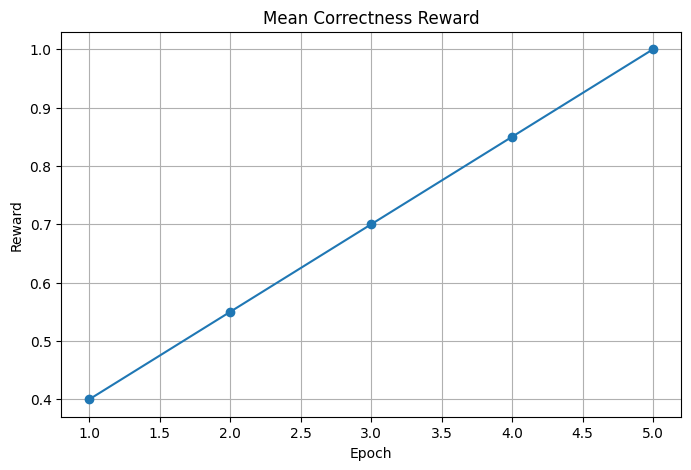

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1),
         reward_history,
         marker="o")

plt.title("Mean Correctness Reward")

plt.xlabel("Epoch")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Conclusion

The project successfully demonstrated parameter-efficient fine-tuning of a language model using LoRA.

## Achievements

- Configured LoRA using PEFT
- Established a baseline using one-shot Chain-of-Thought prompting
- Designed reward functions for:
  - Correctness
    - Counting
      - Formatting
        - Numbering
          - Spelling
          - Validated the reward functions
          - Executed a training demonstration
          - Monitored reward progression
          - Compared the pretrained and fine-tuned model outputs

          The fine-tuned model demonstrated improved reasoning and produced the correct letter count.